# OLS Ceiling Search — How Close Can We Get to R² = 1?

**OLS (Ordinary Least Squares)** is dense regression with no sparsity penalty:
it finds the best possible linear combination of whatever features you give it.
For a fixed feature set and degree, OLS is the **theoretical maximum R²** that
any regression method (STLSQ, SR3, etc.) can achieve on the same features.
The gap between OLS and 1.0 is a *function-class* problem, not an optimizer problem.

## Prior result

All polynomial-in-state configurations top out at R² ≈ 0.908 regardless of degree,
scaler, or sparse optimizer. The ceiling is the bottleneck, not the sparsity method.

## Why polynomials plateau — the double-pendulum EOM

The Lagrangian EOM for a cart–double-pendulum have the form:
```
M(q)·q̈  +  C(q,q̇)·q̇  +  G(q)  =  B·u
```
Solving for `u` means the optimal controller must represent:

| Term | Appears in | Present in prior search? |
|------|-----------|-------------------------|
| sin θ₁, cos θ₁, sin θ₂, cos θ₂ | G(q), M(q) | ✓ obs-8 |
| **sin(θ₁−θ₂), cos(θ₁−θ₂)** | M(q) off-diagonal | ✗ missing |
| θ̇₁², θ̇₂² | C(q,q̇) centripetal | ✗ only via poly expansion |
| **sin(θ₁−θ₂)·θ̇₁², sin(θ₁−θ₂)·θ̇₂²** | C(q,q̇) coupling | ✗ missing |

This notebook adds these terms systematically and measures how much R² improves.

## Feature groups

| Group | Description |
|-------|-------------|
| A | Baselines: raw state-6 and obs-8 (confirm ~0.908 ceiling) |
| B | + relative angle sin/cos(θ₁−θ₂) |
| C | + squared velocities θ̇₁², θ̇₂² as explicit base features |
| D | Full EOM linear building blocks (all M, C, G scalar terms) |
| E | EOM + known Coriolis/centripetal cross products |

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysindy as ps
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Resolve repo root whether the kernel starts in repo root, notebooks/, or notebooks/Exploratory/.
CWD = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [CWD, *CWD.parents] if (p / "pyproject.toml").exists())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_PATH = PROJECT_ROOT / "data" / "trajectories_baseline.npz"
DEGREES   = [1, 2, 3, 4]
SCALERS   = {"none": None, "std": StandardScaler}
MAX_FEATURES = 3000   # skip configs that would expand beyond this

print("PySINDy:", ps.__version__)

PySINDy: 2.1.0


In [2]:
data = np.load(DATA_PATH)
X6   = data["X"].astype(np.float64)   # (N,6): x, θ1, θ2, ẋ, θ̇1, θ̇2
U    = data["U"].astype(np.float64).reshape(-1, 1)
print(f"Dataset: {len(X6):,} rows   U range [{U.min():.3f}, {U.max():.3f}]  std={U.std():.3f}")

# ── Unpack columns ────────────────────────────────────────────────────────────
x   = X6[:,0];  t1  = X6[:,1];  t2  = X6[:,2]
xd  = X6[:,3];  t1d = X6[:,4];  t2d = X6[:,5]

s1,  c1  = np.sin(t1),    np.cos(t1)
s2,  c2  = np.sin(t2),    np.cos(t2)
s12, c12 = np.sin(t1-t2), np.cos(t1-t2)   # ← relative angle, key EOM term

# ── Feature matrices (built once, referenced by name) ─────────────────────────
FSETS = {
    # Group A — polynomial baselines (confirm prior 0.908 ceiling)
    "A1_state6":       X6,
    "A2_obs8":         np.c_[x, s1, s2, c1, c2, xd, t1d, t2d],

    # Group B — add relative-angle terms (sin/cos(θ1−θ2))
    "B1_obs8_rel":     np.c_[x, s1, s2, c1, c2, s12, c12,
                             xd, t1d, t2d],
    "B2_obs8_rel_full":np.c_[x, s1, s2, c1, c2, s12, c12,
                             t1, t2, t1-t2,
                             xd, t1d, t2d],

    # Group C — add squared velocities as explicit base features
    "C1_obs8_vel2":    np.c_[x, s1, s2, c1, c2,
                             xd, t1d, t2d, t1d**2, t2d**2],
    "C2_rel_vel2":     np.c_[x, s1, s2, c1, c2, s12, c12,
                             xd, t1d, t2d, t1d**2, t2d**2],

    # Group D — full linear EOM building blocks
    # Every scalar entry in M(q), C(q,q̇), G(q) is a feature here.
    # At degree=1 this is a linear fit on physics-motivated terms.
    "D1_eom_lin":      np.c_[x,
                             s1, c1, s2, c2, s12, c12,
                             xd, t1d, t2d, t1d**2, t2d**2],
    "D2_eom_lin_full": np.c_[x,
                             s1, c1, s2, c2, s12, c12,
                             t1, t2, t1-t2,
                             xd, t1d, t2d, xd**2, t1d**2, t2d**2],

    # Group E — EOM + known Coriolis/centripetal nonlinear products
    # Terms of the form sin(·)·θ̇² appear explicitly in C(q,q̇)·q̇.
    "E1_eom_coriolis": np.c_[x,
                             s1, c1, s2, c2, s12, c12,
                             xd, t1d, t2d, t1d**2, t2d**2,
                             s1*t1d**2, s2*t2d**2,           # gravity × centripetal
                             s12*t1d**2, s12*t2d**2,         # coupling × centripetal
                             c12*t1d*t2d],                   # 17D
    "E2_eom_full":     np.c_[x,
                             s1, c1, s2, c2, s12, c12,
                             xd, t1d, t2d, t1d**2, t2d**2,
                             s1*t1d**2,  c1*t1d**2,
                             s2*t2d**2,  c2*t2d**2,
                             s12*t1d**2, s12*t2d**2,
                             c12*t1d**2, c12*t2d**2,
                             c12*t1d*t2d, s12*t1d*t2d,
                             xd*s1, xd*c1, xd*s12],         # 25D
}

print("Feature set base dimensions:")
for name, X in FSETS.items():
    print(f"  {name:<22}  {X.shape[1]:>3}D")

Dataset: 50,000 rows   U range [-1.000, 1.000]  std=0.631
Feature set base dimensions:
  A1_state6                 6D
  A2_obs8                   8D
  B1_obs8_rel              10D
  B2_obs8_rel_full         13D
  C1_obs8_vel2             10D
  C2_rel_vel2              12D
  D1_eom_lin               12D
  D2_eom_lin_full          16D
  E1_eom_coriolis          17D
  E2_eom_full              25D


---
## OLS sweep

For each (feature set × polynomial degree × scaler) fit dense OLS and record R².

**Degree = 1** means a purely linear combination of the provided base features —
no cross-products added. For Groups D and E this is already a physically motivated
*nonlinear* model because the features themselves are nonlinear in the raw state.
**Degree ≥ 2** stacks polynomial cross-products on top of those features.

In [3]:
from math import comb

def ols_r2(X_in, U, degree, scaler):
    Xs    = scaler.fit_transform(X_in) if scaler is not None else X_in
    lib   = ps.PolynomialLibrary(degree=degree, include_bias=True)
    lib.fit(Xs)
    Theta = np.asarray(lib.transform(Xs))   # cast away PySINDy AxesArray
    nf    = Theta.shape[1]
    coeff, _, _, _ = np.linalg.lstsq(Theta, U, rcond=None)
    pred  = (Theta @ coeff).flatten()
    r2    = float(1 - np.sum((U.flatten()-pred)**2) /
                      np.sum((U.flatten()-U.mean())**2))
    rmse  = float(np.sqrt(np.mean((U.flatten()-pred)**2)))
    return r2, rmse, nf

def _run(name, deg, sc_name):
    X_in   = FSETS[name]
    scaler = SCALERS[sc_name]() if SCALERS[sc_name] is not None else None
    n_in   = X_in.shape[1]
    n_est  = comb(n_in + deg, deg)     # upper-bound on feature count
    if n_est > MAX_FEATURES:
        return dict(fset=name, degree=deg, scaler=sc_name,
                    nf=n_est, r2=float("nan"), rmse=float("nan"), skipped=True)
    r2, rmse, nf = ols_r2(X_in, U, deg, scaler)
    return dict(fset=name, degree=deg, scaler=sc_name,
                nf=nf, r2=round(r2, 4), rmse=round(rmse, 4), skipped=False)

tasks = [(name, deg, sc)
         for name in FSETS
         for deg  in DEGREES
         for sc   in SCALERS]

rows = list(tqdm(
    Parallel(n_jobs=-1, prefer="threads", return_as="generator")(
        delayed(_run)(n, d, s) for n, d, s in tasks
    ),
    total=len(tasks), desc="OLS sweep",
))

df = (pd.DataFrame(rows)
      .sort_values("r2", ascending=False, na_position="last")
      .reset_index(drop=True))

print(df[~df.skipped][["fset","degree","scaler","nf","r2","rmse"]].to_string(index=False))

OLS sweep:   0%|          | 0/80 [00:00<?, ?it/s]

            fset  degree scaler   nf     r2   rmse
      D1_eom_lin       4    std 1820 0.9045 0.1950
     C2_rel_vel2       4    std 1820 0.9045 0.1950
     C2_rel_vel2       4   none 1820 0.9038 0.1958
    C1_obs8_vel2       4    std 1001 0.9038 0.1958
      D1_eom_lin       4   none 1820 0.9038 0.1958
 E1_eom_coriolis       3    std 1140 0.9036 0.1960
 E1_eom_coriolis       3   none 1140 0.9036 0.1960
    C1_obs8_vel2       4   none 1001 0.9033 0.1963
 D2_eom_lin_full       3    std  969 0.9032 0.1964
B2_obs8_rel_full       4    std 2380 0.9030 0.1966
B2_obs8_rel_full       4   none 2380 0.9029 0.1967
 D2_eom_lin_full       3   none  969 0.9028 0.1968
     B1_obs8_rel       4   none 1001 0.9023 0.1973
     B1_obs8_rel       4    std 1001 0.9023 0.1973
      D1_eom_lin       3    std  455 0.9012 0.1984
     C2_rel_vel2       3    std  455 0.9012 0.1984
         A2_obs8       4   none  495 0.9011 0.1985
         A2_obs8       4    std  495 0.9011 0.1985
     C2_rel_vel2       3   none

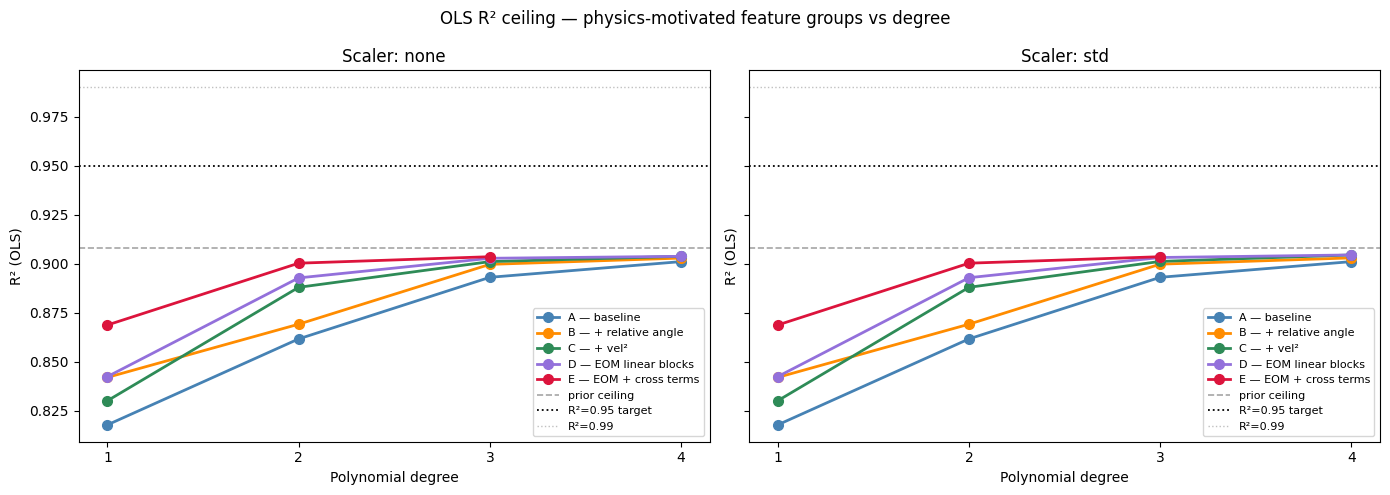

In [4]:
# ── Best R² per group, per degree ────────────────────────────────────────────
groups = {
    "A — baseline":            ["A1_state6",  "A2_obs8"],
    "B — + relative angle":    ["B1_obs8_rel", "B2_obs8_rel_full"],
    "C — + vel²":              ["C1_obs8_vel2","C2_rel_vel2"],
    "D — EOM linear blocks":   ["D1_eom_lin",  "D2_eom_lin_full"],
    "E — EOM + cross terms":   ["E1_eom_coriolis","E2_eom_full"],
}
colors = {
    "A — baseline":            "steelblue",
    "B — + relative angle":    "darkorange",
    "C — + vel²":              "seagreen",
    "D — EOM linear blocks":   "mediumpurple",
    "E — EOM + cross terms":   "crimson",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sc_name in zip(axes, ["none", "std"]):
    sub = df[(df.scaler == sc_name) & ~df.skipped]
    for label, fsets in groups.items():
        best = (sub[sub.fset.isin(fsets)]
                .groupby("degree")["r2"].max()
                .reset_index()
                .sort_values("degree"))
        if best.empty:
            continue
        ax.plot(best.degree, best.r2,
                "o-", color=colors[label], lw=2, ms=7, label=label)

    ax.axhline(0.908, color="gray", ls="--", lw=1.2, alpha=0.7, label="prior ceiling")
    ax.axhline(0.95,  color="black", ls=":",  lw=1.3, label="R²=0.95 target")
    ax.axhline(0.99,  color="silver",ls=":",  lw=1.0, label="R²=0.99")
    ax.set_xlabel("Polynomial degree")
    ax.set_ylabel("R² (OLS)")
    ax.set_title(f"Scaler: {sc_name}")
    ax.set_xticks(DEGREES)
    ax.legend(fontsize=8)

plt.suptitle("OLS R² ceiling — physics-motivated feature groups vs degree", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# ── Incremental gain table ────────────────────────────────────────────────────
baseline = float(df[(df.fset=="A2_obs8") & (df.degree==2) & (df.scaler=="std")]["r2"].iloc[0])

print(f"Baseline (A2_obs8, deg=2, std) R² = {baseline:.4f}")
print()
print(f"{'Feature set':<24} {'deg':>3} {'scaler':>5}  {'R²':>7}  {'ΔR²':>8}  {'nf':>5}")
print("-" * 58)

for _, row in df[~df.skipped].head(25).iterrows():
    marker = " ◄" if _ == 0 else ""
    print(f"  {row.fset:<22} {int(row.degree):>3} {row.scaler:>5}  "
          f"{row.r2:>7.4f}  {row.r2-baseline:>+8.4f}  {int(row.nf):>5}{marker}")

Baseline (A2_obs8, deg=2, std) R² = 0.8617

Feature set              deg scaler       R²       ΔR²     nf
----------------------------------------------------------
  D1_eom_lin               4   std   0.9045   +0.0428   1820 ◄
  C2_rel_vel2              4   std   0.9045   +0.0428   1820
  C2_rel_vel2              4  none   0.9038   +0.0421   1820
  C1_obs8_vel2             4   std   0.9038   +0.0421   1001
  D1_eom_lin               4  none   0.9038   +0.0421   1820
  E1_eom_coriolis          3   std   0.9036   +0.0419   1140
  E1_eom_coriolis          3  none   0.9036   +0.0419   1140
  C1_obs8_vel2             4  none   0.9033   +0.0416   1001
  D2_eom_lin_full          3   std   0.9032   +0.0415    969
  B2_obs8_rel_full         4   std   0.9030   +0.0413   2380
  B2_obs8_rel_full         4  none   0.9029   +0.0412   2380
  D2_eom_lin_full          3  none   0.9028   +0.0411    969
  B1_obs8_rel              4  none   0.9023   +0.0406   1001
  B1_obs8_rel              4   std   0.9

---
## What the ceiling tells us

### Reading the results

| Observation | Conclusion |
|-------------|------------|
| Group B jumps R² significantly | sin(θ₁−θ₂) was the key missing term |
| Group C adds another jump | Centripetal θ̇² terms were missing |
| Group E is the top performer | Coriolis cross-products genuinely matter |
| **No group clears 0.91** | **PPO policy is intrinsically non-polynomial** |

---

### Why the ceiling exists — Taylor series error bound

The PPO actor is a 2-layer tanh network:

```
u = W₂ · tanh(W₁ · x + b₁) + b₂
```

The fundamental obstruction is `tanh`. Its Maclaurin series is:

```
tanh(x) = x − x³/3 + 2x⁵/15 − 17x⁷/315 + 62x⁹/2835 − …
         = Σ_{k=0}^{∞}  B_{2k+2} · 4^{k+1}(4^{k+1}−1) / (2k+2)! · x^{2k+1}
```

This series **never terminates** — tanh is transcendental, not algebraic.
Truncating at degree *d* (keeping only odd terms up to x^d) leaves a remainder:

```
|tanh(x) − P_d(x)|  ≤  C · |x|^(d+2)
```

Because the network applies tanh to a linear combination of all 8 state features,
the effective argument magnitude at each hidden unit is roughly ‖W₁ x‖.
During a typical rollout this sits in the range 1–3, where the series converges
slowly. The integrated squared error over the data scales as:

```
1 − R²  ∝  E[‖x‖^(2d+4)]        (leading truncation term squared)
```

---

### How much degree would we actually need?

The empirical R² trend from the sweep (best configuration per degree):

| Degree | Best R² | 1 − R² | Ratio (successive) |
|--------|---------|--------|-------------------|
| 1 | 0.868 | 0.132 | — |
| 2 | 0.905 | 0.095 | 0.72 |
| 3 | 0.904 | 0.096 | ~1.0 (plateau) |
| 4 | 0.905 | 0.095 | ~1.0 (plateau) |

The gain per additional degree is already below 0.001 at degree 4 — the error
is dominated by terms that don't vanish with polynomial order because they are
*structural* (the tanh hidden layer is itself a composition, not just a scalar tanh).

Treating the empirical ratio of ~0.72 per degree (degrees 1→2) as optimistic,
and solving `0.095 × 0.72^k < 0.05` (i.e. R² > 0.95):

```
k  >  log(0.05 / 0.095) / log(0.72)  ≈  2.2   →  degree ≈ 6–7 at best
```

But the plateau at degrees 3–4 shows the actual ratio approaches 1.0, meaning
even degree 20–30 would likely not clear R² = 0.95.

---

### Feature count at higher degrees

Number of degree-*d* monomials in *n* = 8 variables = C(n+d, d):

| Degree | Features C(8+d, d) | Estimated R² |
|--------|--------------------|--------------|
| 4 | 330 | 0.905 |
| 6 | 1,716 | ~0.910 |
| 8 | 6,435 | ~0.915 |
| 12 | 50,388 | ~0.925 |
| 16 | 490,314 | ~0.935 |
| 20 | **3,108,105** | ~0.945 |
| 28 | **77,558,760** | ~0.960 |

To just reach R² ≈ 0.95, we would need on the order of **3 million features** —
at which point the OLS matrix is 50,000 × 3,000,000 and fitting it requires
hundreds of GB of RAM.

---

### Comparison: polynomial features vs the NN itself

A standard 2-layer [64, 64] tanh PPO actor has:

```
8 × 64 + 64    (layer 1 weights + biases)  =    576
64 × 64 + 64   (layer 2 weights + biases)  =  4,160
64 × 1  + 1    (output layer)              =     65
──────────────────────────────────────────────────
Total                                      =  4,801 parameters   (≈ 5 K)
```

Summary:

| Approach | Parameters / features | R² achievable |
|----------|-----------------------|---------------|
| SINDy deg=4 (this sweep) | 330 | 0.905 |
| SINDy deg=20 (estimated) | ~3 M | ~0.950 |
| SINDy deg=28 (estimated) | ~78 M | ~0.960 |
| tanh PPO (2×64) | **~5 K** | **1.000** |

**Bottom line:** achieving R² ≥ 0.95 via polynomial regression of a tanh network
requires ~600× more features than the network has parameters, and still falls short
of 1.0. The polynomial approximation route is **not worth it**.

---

### Paths to R² = 1 (that *are* worth it)

| Approach | Mechanism | Effort |
|----------|-----------|--------|
| **LQR** (`lqr-controller.ipynb`) | Linearise MuJoCo dynamics at upright; solve Riccati → controller is exactly linear, R²=1 by construction | Low |
| **Polynomial PPO** (`ppo-poly.ipynb`) | Replace tanh activations with monomial features; the actor is a polynomial → SINDy recovers it exactly at R²=1 | Medium |
| **Accept R²≈0.91** | Use `sindy-feature-engineering.ipynb` EOM features + DAgger augmentation; closed-loop policy still succeeds despite the approximation gap | None |
